# XClinVision: Data Exploration Notebook
**Day 1: EDA & Data Preparation**

This notebook explores the chest X-ray dataset structure, visualizes samples,
and analyzes class distributions for the XClinVision project.

## 1. Setup and Imports

In [ ]:
import os
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path().absolute().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from xclinvision.processing import (
    load_dataset_metadata,
    IMAGE_EXTS,
    DEFAULT_MIN_AREA_RATIO,
)

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
%load_ext autoreload
%autoreload 2

## 2. Dataset Paths Configuration

In [9]:
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"Data directory: {DATA_DIR}")
print(f"Raw data exists: {RAW_DIR.exists()}")
print(f"Processed data exists: {PROCESSED_DIR.exists()}")

Data directory: ../data
Raw data exists: True
Processed data exists: True


In [3]:
2000 / 12

166.66666666666666

## 3. Load Dataset Metadata

In [11]:
# load_dataset_metadata is imported from xclinvision.processing
# It scans raw_dir/{split}/{class}/ for images matching IMAGE_EXTS.

df = load_dataset_metadata(RAW_DIR)
print(f"\nTotal images: {len(df)}")
if len(df) > 0:
    print(f"\nPer split/class breakdown:")
    print(df.groupby(["split", "class"]).size().unstack(fill_value=0))
df.head()

Scanning train:   0%|          | 0/3 [00:00<?, ?it/s]

  normal:   0%|          | 0/7263 [00:00<?, ?it/s]

  pneumonia:   0%|          | 0/4674 [00:00<?, ?it/s]

  tuberculosis:   0%|          | 0/8513 [00:00<?, ?it/s]

Scanning val:   0%|          | 0/3 [00:00<?, ?it/s]

...

  normal:   0%|          | 0/925 [00:00<?, ?it/s]

  pneumonia:   0%|          | 0/580 [00:00<?, ?it/s]

  tuberculosis:   0%|          | 0/1064 [00:00<?, ?it/s]


Total images: 25553

Per split/class breakdown:
class  normal  pneumonia  tuberculosis
split                                 
test      925        580          1064
train    7263       4674          8513
val       900        570          1064


,split,class,filepath,filename
0,train,normal,../data/raw/train/normal/normal-3873.jpg,normal-3873.jpg
1,train,normal,../data/raw/train/normal/normal-3378.jpg,normal-3378.jpg
2,train,normal,../data/raw/train/normal/normal-3535.jpg,normal-3535.jpg
3,train,normal,../data/raw/train/normal/normal-6820.jpg,normal-6820.jpg
4,train,normal,../data/raw/train/normal/normal-1343.jpg,normal-1343.jpg


## 4. Class Distribution Analysis

Class Distribution:
class
tuberculosis    10641
normal           9088
pneumonia        5824
Name: count, dtype: int64


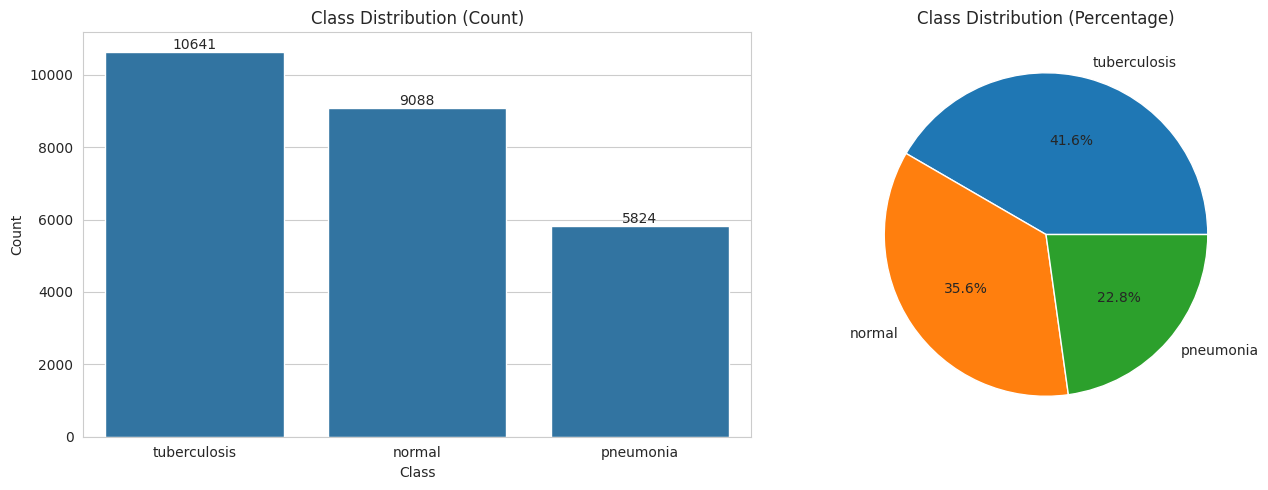

In [12]:
# Overall class distribution
class_counts = df["class"].value_counts()
print("Class Distribution:")
print(class_counts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%")
axes[1].set_title("Class Distribution (Percentage)")

plt.tight_layout()
plt.show()

## 5. Per-Split Class Distribution
Verify that the class balance is consistent across train, validation, and test splits.

Per-Split Class Counts:
class  normal  pneumonia  tuberculosis
split                                 
test     1231        650          1429
train    8960       8841         10250
val       985        578          1432



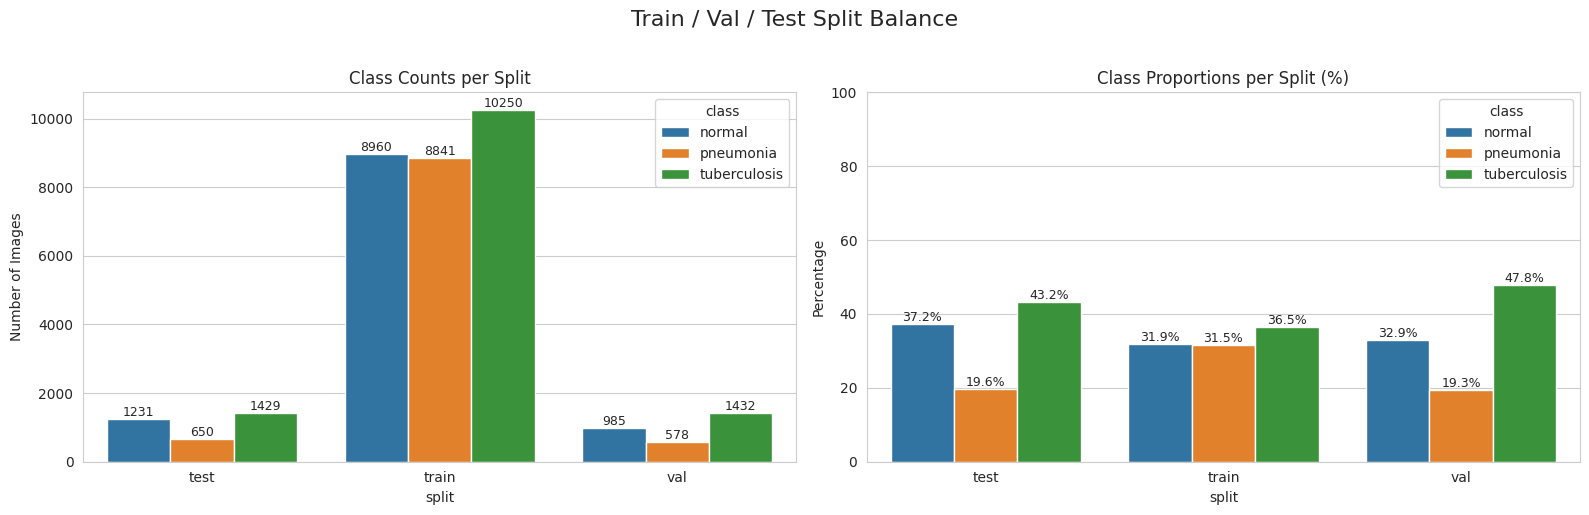

In [6]:
# Per-split class counts
split_class = df.groupby(["split", "class"]).size().unstack(fill_value=0)
print("Per-Split Class Counts:")
print(split_class)
print()

# Grouped bar chart
split_class_melted = split_class.reset_index().melt(id_vars="split", var_name="class", value_name="count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
sns.barplot(data=split_class_melted, x="split", y="count", hue="class", ax=axes[0])
axes[0].set_title("Class Counts per Split")
axes[0].set_ylabel("Number of Images")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=9)

# Proportions within each split
split_pct = split_class.div(split_class.sum(axis=1), axis=0) * 100
split_pct_melted = split_pct.reset_index().melt(id_vars="split", var_name="class", value_name="percentage")

sns.barplot(data=split_pct_melted, x="split", y="percentage", hue="class", ax=axes[1])
axes[1].set_title("Class Proportions per Split (%)")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0, 100)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", fontsize=9)

plt.suptitle("Train / Val / Test Split Balance", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Sample Image Visualization

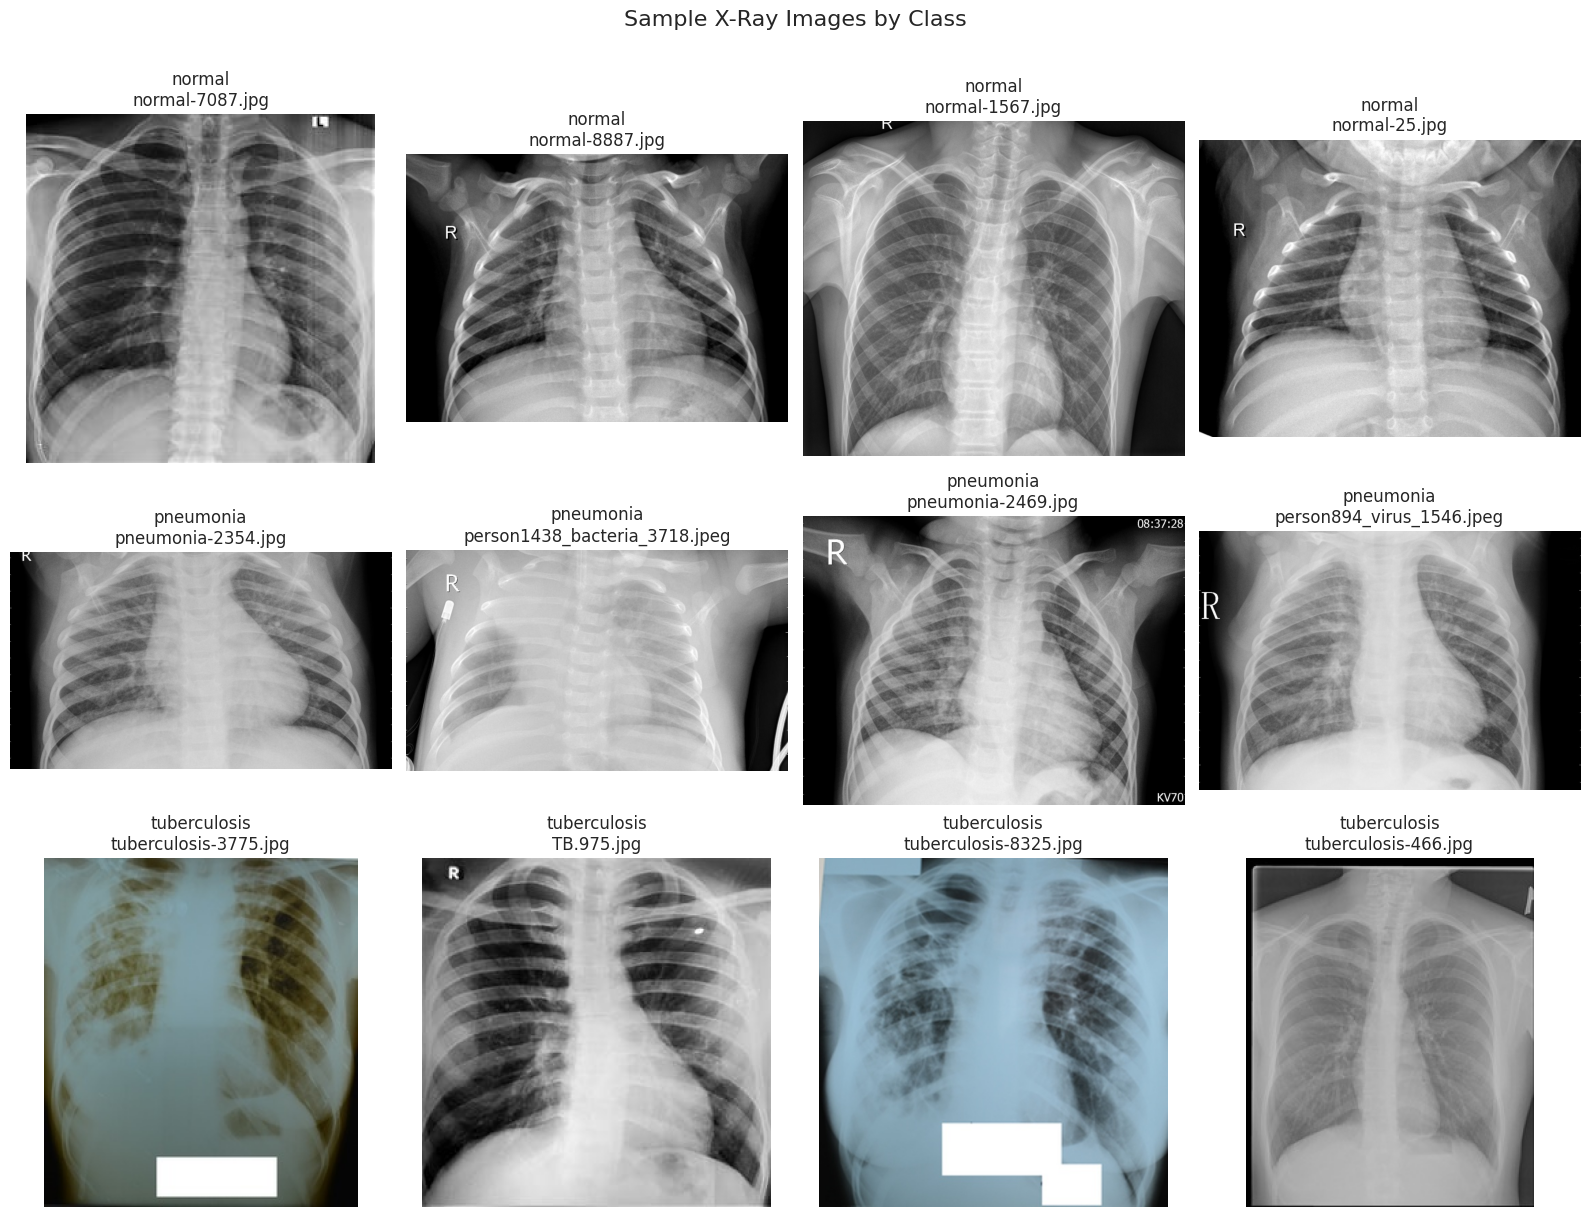

In [7]:
def visualize_samples(df: pd.DataFrame, n_samples: int = 4):
    """Visualize sample images from each class (n_samples per row)."""
    
    classes = sorted(df["class"].unique())
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 4, n_classes * 4))
    
    for i, class_name in enumerate(classes):
        class_df = df[df["class"] == class_name]
        samples = class_df.sample(n=min(n_samples, len(class_df)))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row["filepath"])
            if n_classes == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{class_name}\n{row['filename'][:30]}")
            ax.axis("off")
    
    plt.suptitle("Sample X-Ray Images by Class", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

# Show samples
if len(df) > 0:
    visualize_samples(df, n_samples=4)
else:
    print("No images found. Please download datasets first.")

## 7. Image Resolution & Size Distribution
Analyze width, height, and aspect ratio across the dataset to inform preprocessing resize choices.

In [27]:
def get_image_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Collect width, height, channels, and file size for each image."""
    stats = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Scanning images"):
        try:
            img = Image.open(row["filepath"])
            w, h = img.size
            mode = img.mode  # 'L' = grayscale, 'RGB', etc.
            channels = len(img.getbands())
            file_size_kb = os.path.getsize(row["filepath"]) / 1024
            stats.append({
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 3),
                "mode": mode,
                "channels": channels,
                "file_size_kb": round(file_size_kb, 1),
            })
        except Exception as e:
            stats.append({
                "width": None, "height": None, "aspect_ratio": None,
                "mode": None, "channels": None, "file_size_kb": None,
            })
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(stats)], axis=1)

df_stats = get_image_stats(df)

Scanning images:   0%|          | 0/25553 [00:00<?, ?it/s]

In [9]:
df_stats[["filename", "class", "split", "width", "height", "aspect_ratio", "mode", "channels", "file_size_kb"]]

,filename,class,split,width,height,aspect_ratio,mode,channels,file_size_kb
0,normal-3873.jpg,normal,train,1024,1024,1.000,RGB,3,180.9
1,IM-0525-0001-0001.jpeg,normal,train,1268,1017,1.247,L,1,342.3
2,normal-3378.jpg,normal,train,1932,1908,1.013,RGB,3,788.7
3,normal-3535.jpg,normal,train,512,512,1.000,RGB,3,54.6
4,NORMAL2-IM-1128-0001-0002.jpeg,normal,train,1414,1164,1.215,L,1,418.3
...,...,...,...,...,...,...,...,...,...
34351,tuberculosis-208.jpg,tuberculosis,test,256,226,1.133,RGB,3,14.7
34352,TB.303.jpg,tuberculosis,test,252,221,1.140,RGB,3,35.0
34353,tuberculosis-205.jpg,tuberculosis,test,512,512,1.000,RGB,3,57.9
34354,TB.881.jpg,tuberculosis,test,256,256,1.000,RGB,3,9.3


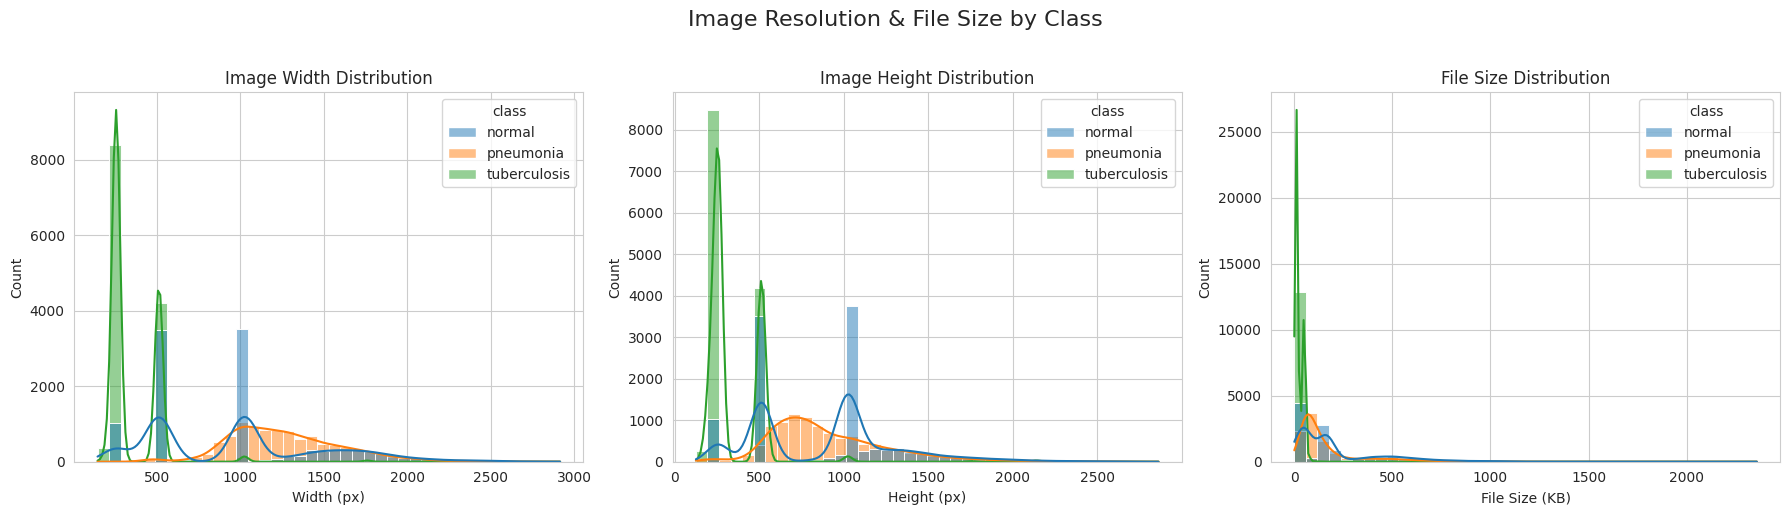


Top 10 most common resolutions (W x H):
  512 x 512: 7694 images
  256 x 256: 6938 images
  1024 x 1024: 3625 images
  256 x 211: 887 images
  211 x 256: 311 images
  256 x 192: 114 images
  256 x 246: 94 images
  256 x 191: 60 images
  256 x 204: 32 images
  256 x 215: 29 images


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
sns.histplot(data=df_stats, x="width", hue="class", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

# Height distribution
sns.histplot(data=df_stats, x="height", hue="class", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

# File size distribution
sns.histplot(data=df_stats, x="file_size_kb", hue="class", bins=40, kde=True, ax=axes[2])
axes[2].set_title("File Size Distribution")
axes[2].set_xlabel("File Size (KB)")

plt.suptitle("Image Resolution & File Size by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Most common resolutions
print("\nTop 10 most common resolutions (W x H):")
res_counts = df_stats.groupby(["width", "height"]).size().sort_values(ascending=False).head(10)
for (w, h), count in res_counts.items():
    print(f"  {w} x {h}: {count} images")

## 8. Pixel Intensity Histograms per Class
Compare mean pixel intensity distributions — can reveal scanning protocol or contrast differences between classes.

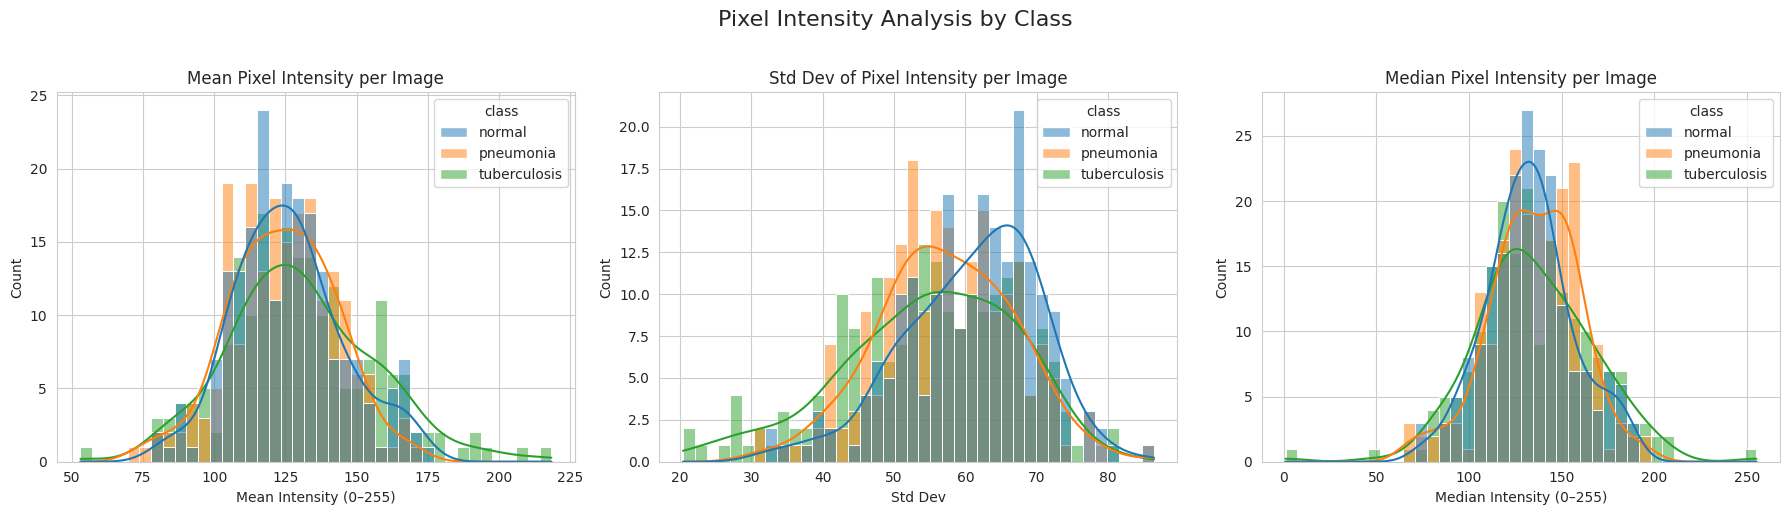


Intensity Statistics by Class:
             mean_intensity            std_intensity      
                       mean        std          mean   std
class                                                     
normal           126.000000  19.000000     60.900002   9.4
pneumonia        124.000000  18.700001     57.200001   9.5
tuberculosis     130.399994  25.799999     54.900002  12.1


In [11]:
def compute_mean_pixel_intensity(df: pd.DataFrame, sample_n: int = 200) -> pd.DataFrame:
    """Compute mean pixel intensity for a sample of images per class."""
    records = []
    for cls in df["class"].unique():
        class_df = df[df["class"] == cls]
        sample = class_df.sample(n=min(sample_n, len(class_df)), random_state=42)
        for _, row in sample.iterrows():
            try:
                img = Image.open(row["filepath"]).convert("L")  # grayscale
                arr = np.array(img, dtype=np.float32)
                records.append({
                    "class": cls,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "median_intensity": np.median(arr),
                })
            except Exception:
                continue
    return pd.DataFrame(records)

intensity_df = compute_mean_pixel_intensity(df, sample_n=200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean intensity
sns.histplot(data=intensity_df, x="mean_intensity", hue="class", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Mean Pixel Intensity per Image")
axes[0].set_xlabel("Mean Intensity (0–255)")

# Std intensity
sns.histplot(data=intensity_df, x="std_intensity", hue="class", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Std Dev of Pixel Intensity per Image")
axes[1].set_xlabel("Std Dev")

# Median intensity
sns.histplot(data=intensity_df, x="median_intensity", hue="class", bins=40, kde=True, ax=axes[2])
axes[2].set_title("Median Pixel Intensity per Image")
axes[2].set_xlabel("Median Intensity (0–255)")

plt.suptitle("Pixel Intensity Analysis by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nIntensity Statistics by Class:")
print(intensity_df.groupby("class")[["mean_intensity", "std_intensity"]].agg(["mean", "std"]).round(1))

## 9. Processed Data — Per-Split Class Distribution
Load the processed manifest generated by `run_processing_pipeline` and verify class balance is preserved after preprocessing.

Processed images: 14354

Per split/class breakdown:
class  normal  pneumonia  tuberculosis
split                                 
test      336        433           660
train    2829       3394          5295
val       335        411           661


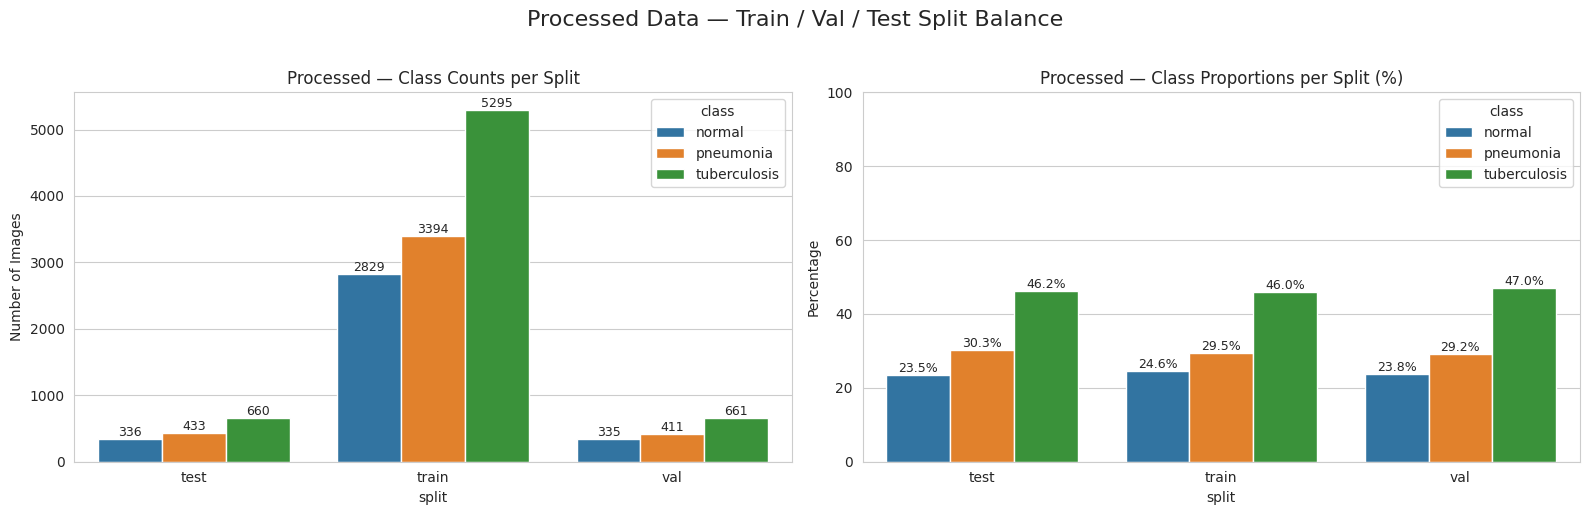


--- Raw vs Processed Comparison ---
Images removed during processing (raw - processed):
class  normal  pneumonia  tuberculosis
split                                 
test      589        147           404
train    4434       1280          3218
val       565        159           403


In [17]:
# Load the processed manifest
PROJECT_ROOT = Path().absolute().parent  # notebooks/ -> project root
QUARANTINE_DIR = DATA_DIR / "quarantine"
processed_manifest_path = PROCESSED_DIR / "manifest.csv"

if processed_manifest_path.exists():
    df_processed = pd.read_csv(processed_manifest_path)
    
    # Manifest paths are relative to the project root — resolve them
    df_processed["filepath_processed"] = df_processed["filepath_processed"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )
    df_processed["filepath_original"] = df_processed["filepath_original"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )
    
    print(f"Processed images: {len(df_processed)}")
    print(f"\nPer split/class breakdown:")
    proc_split_class = df_processed.groupby(["split", "class"]).size().unstack(fill_value=0)
    print(proc_split_class)

    # Grouped bar chart
    proc_melted = proc_split_class.reset_index().melt(
        id_vars="split", var_name="class", value_name="count"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Absolute counts
    sns.barplot(data=proc_melted, x="split", y="count", hue="class", ax=axes[0])
    axes[0].set_title("Processed — Class Counts per Split")
    axes[0].set_ylabel("Number of Images")
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%d", fontsize=9)

    # Proportions
    proc_pct = proc_split_class.div(proc_split_class.sum(axis=1), axis=0) * 100
    proc_pct_melted = proc_pct.reset_index().melt(
        id_vars="split", var_name="class", value_name="percentage"
    )
    sns.barplot(data=proc_pct_melted, x="split", y="percentage", hue="class", ax=axes[1])
    axes[1].set_title("Processed — Class Proportions per Split (%)")
    axes[1].set_ylabel("Percentage")
    axes[1].set_ylim(0, 100)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.1f%%", fontsize=9)

    plt.suptitle("Processed Data — Train / Val / Test Split Balance", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Compare raw vs processed counts
    print("\n--- Raw vs Processed Comparison ---")
    raw_counts = df.groupby(["split", "class"]).size().unstack(fill_value=0)
    diff = raw_counts - proc_split_class.reindex_like(raw_counts).fillna(0).astype(int)
    print("Images removed during processing (raw - processed):")
    print(diff)
else:
    print(f"⚠️  Processed manifest not found at {processed_manifest_path}")
    print("   Run the processing pipeline first: python -m xclinvision.processing")
    df_processed = pd.DataFrame()

## 10. Quarantined Data — Corrupted & Flagged Samples
Visualize images quarantined by the processing pipeline (`process_and_filter_xray`).
- **Corrupted**: images that failed to load or are blank / near-uniform
- **Flagged**: images filtered due to too-small X-ray content area (ratio < `DEFAULT_MIN_AREA_RATIO = 0.15`)

Total quarantined images: 20

Breakdown by category:
category
Flagged      19
Corrupted     1
Name: count, dtype: int64

Per split/class/category:
class            pneumonia  tuberculosis
category  split                         
Corrupted train          0             1
Flagged   test           0             2
          train          7             9
          val            0             1


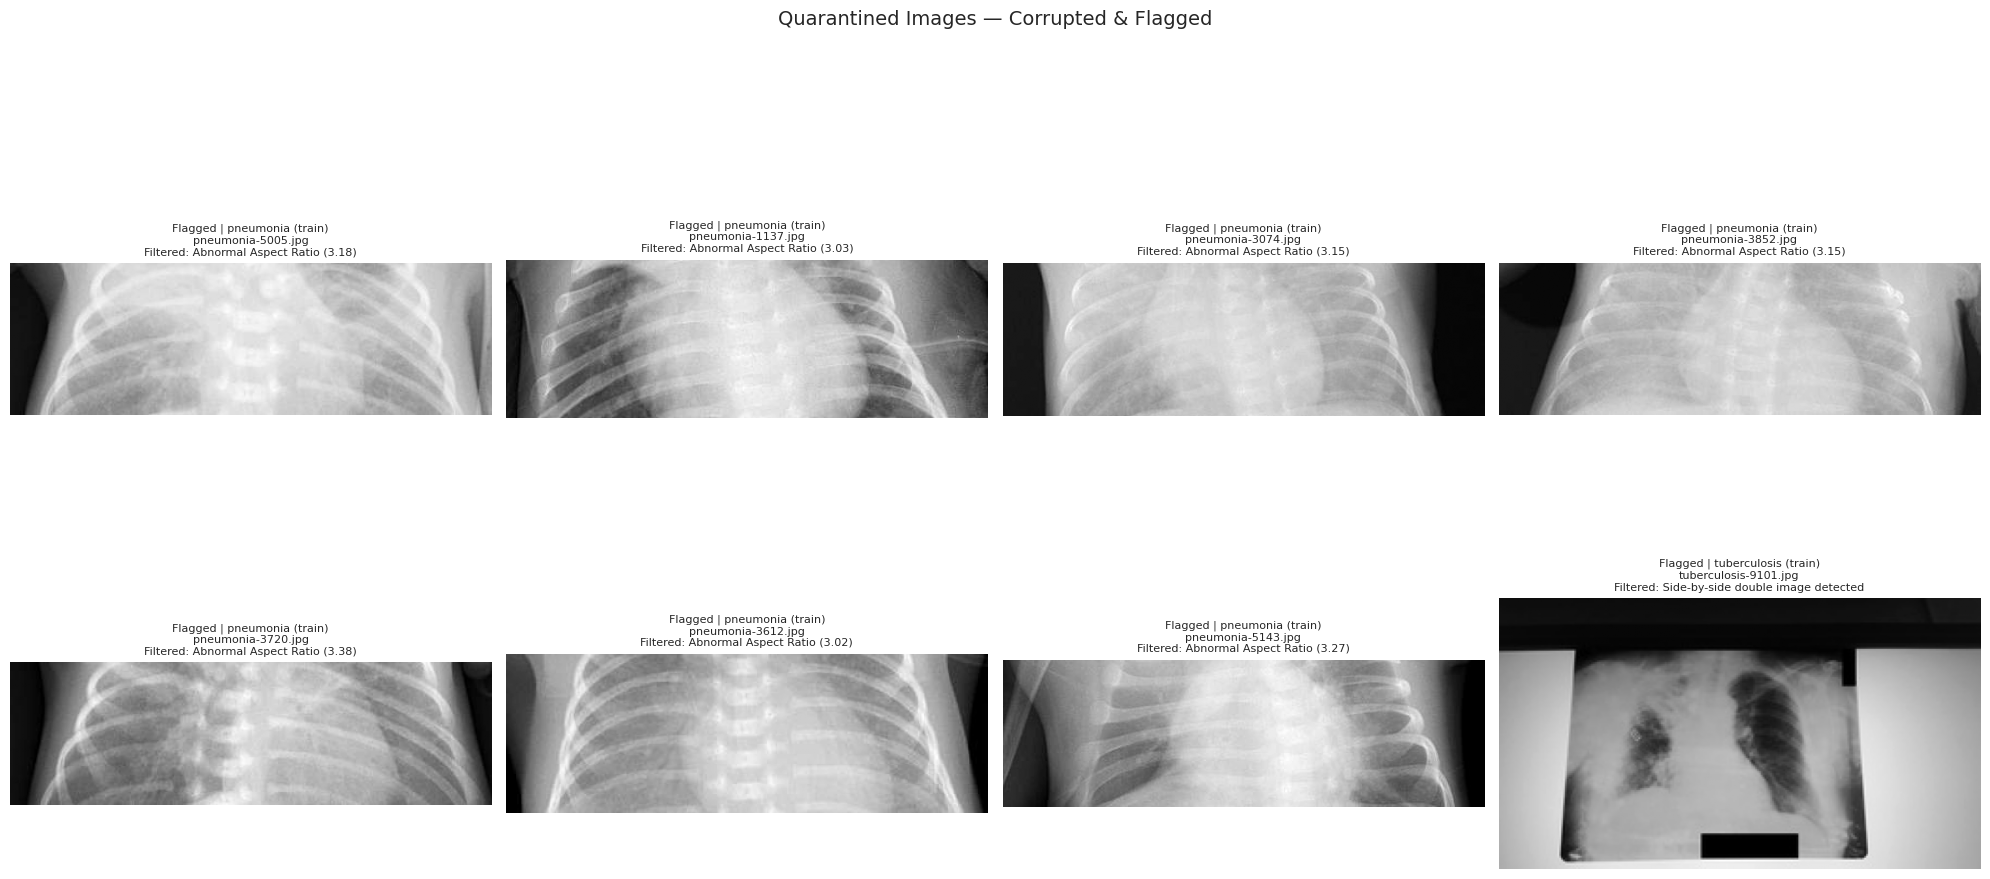


Quarantine Reasons:
  Filtered: Side-by-side double image detected: 6
  Filtered: Abnormal Aspect Ratio (3.15): 2
  Filtered: X-ray area too small (0.15): 2
  Filtered: X-ray area too small (0.12): 2
  Filtered: Abnormal Aspect Ratio (3.18): 1
  Filtered: Abnormal Aspect Ratio (3.03): 1
  Filtered: Abnormal Aspect Ratio (3.38): 1
  Filtered: Abnormal Aspect Ratio (3.02): 1
  Filtered: Abnormal Aspect Ratio (3.27): 1
  Error: Image is blank or near-uniform (std=1.76): 1
  Filtered: X-ray area too small (0.14): 1
  Filtered: X-ray area too small (0.13): 1


In [29]:
quarantine_manifest_path = QUARANTINE_DIR / "quarantine_manifest.csv"

if quarantine_manifest_path.exists():
    df_quarantine = pd.read_csv(quarantine_manifest_path)
    
    # Resolve relative paths from project root
    for col in ["filepath_original", "filepath_quarantine"]:
        df_quarantine[col] = df_quarantine[col].apply(lambda p: str(PROJECT_ROOT / p))
    
    print(f"Total quarantined images: {len(df_quarantine)}")
    
    df_quarantine["category"] = df_quarantine["reason"].apply(
        lambda r: "Corrupted" if r.startswith("Error") else "Flagged"
    )
    print(f"\nBreakdown by category:")
    print(df_quarantine["category"].value_counts())
    print(f"\nPer split/class/category:")
    print(df_quarantine.groupby(["category", "split", "class"]).size().unstack(fill_value=0))

    # --- Visualize quarantined samples ---
    n_show = min(8, len(df_quarantine))
    if n_show > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        for idx, (_, row) in enumerate(df_quarantine.head(n_show).iterrows()):
            ax = axes[idx]
            try:
                img = Image.open(row["filepath_quarantine"]).convert("L")
                ax.imshow(np.array(img), cmap="gray")
            except Exception:
                ax.text(0.5, 0.5, "Cannot\nLoad", ha="center", va="center",
                        fontsize=14, color="red", transform=ax.transAxes)

            ax.set_title(
                f"{row['category']} | {row['class']} ({row['split']})\n"
                f"{Path(row['filepath_original']).name[:35]}\n"
                f"{row['reason'][:50]}",
                fontsize=8,
            )
            ax.axis("off")

        for idx in range(n_show, len(axes)):
            axes[idx].axis("off")

        plt.suptitle("Quarantined Images — Corrupted & Flagged", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()

    # Reason summary
    print("\nQuarantine Reasons:")
    for reason, count in df_quarantine["reason"].value_counts().items():
        print(f"  {reason}: {count}")
else:
    print(f"⚠️  Quarantine manifest not found at {quarantine_manifest_path}")
    print("   Run the processing pipeline first.")
    df_quarantine = pd.DataFrame()

## 11. Processed Data — Image Resolution & Size Distribution
Verify that all processed images have the expected target dimensions after preprocessing (auto-crop + CLAHE + letterbox resize).

Scanning processed images:   0%|          | 0/14354 [00:00<?, ?it/s]

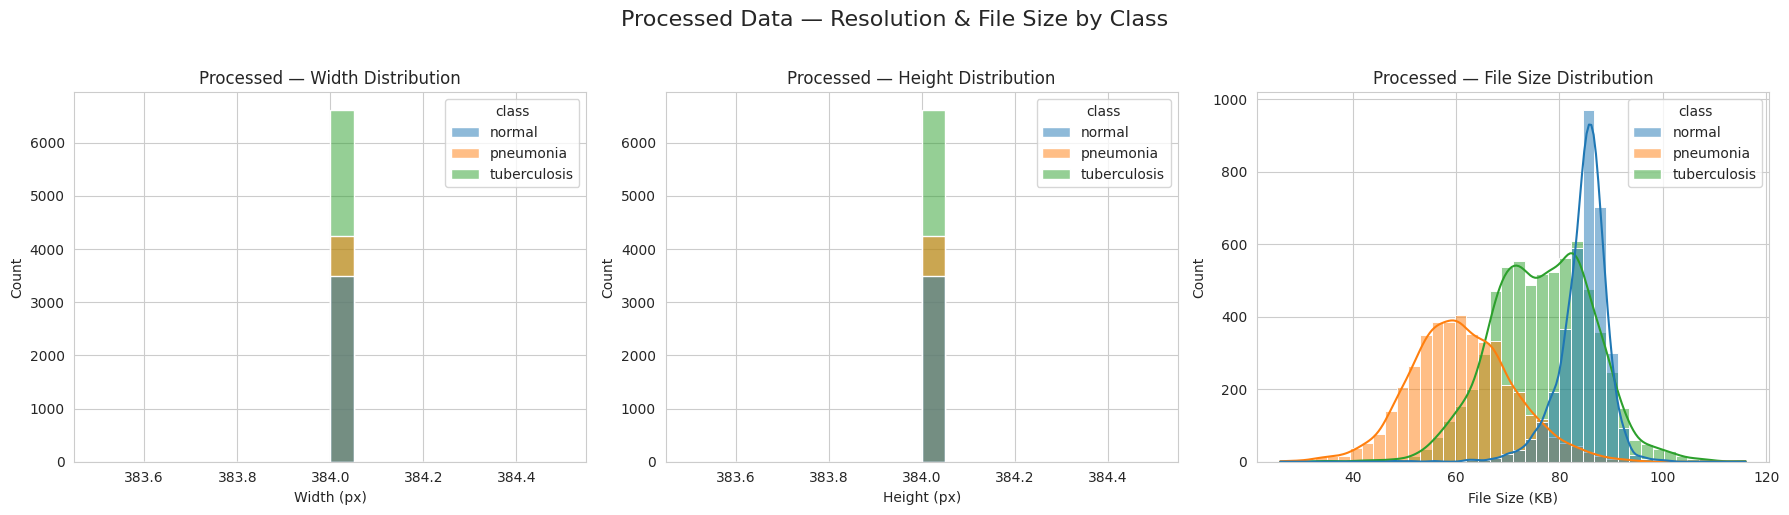


Unique resolutions in processed data:
  384 x 384: 14354 images


In [24]:
if not df_processed.empty:
    proc_stats = []
    for _, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc="Scanning processed images"):
        try:
            img = Image.open(row["filepath_processed"])
            w, h = img.size
            file_size_kb = os.path.getsize(row["filepath_processed"]) / 1024
            proc_stats.append({
                "width": w, "height": h,
                "aspect_ratio": round(w / h, 3),
                "file_size_kb": round(file_size_kb, 1),
            })
        except Exception:
            proc_stats.append({"width": None, "height": None, "aspect_ratio": None, "file_size_kb": None})

    df_proc_stats = pd.concat([df_processed.reset_index(drop=True), pd.DataFrame(proc_stats)], axis=1)

    # Only use kde=True when there are multiple unique values (all processed
    # images may share identical target dimensions, causing kde to fail).
    use_kde_w = df_proc_stats["width"].nunique() > 1
    use_kde_h = df_proc_stats["height"].nunique() > 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(data=df_proc_stats, x="width", hue="class", bins=20, kde=use_kde_w, ax=axes[0])
    axes[0].set_title("Processed — Width Distribution")
    axes[0].set_xlabel("Width (px)")

    sns.histplot(data=df_proc_stats, x="height", hue="class", bins=20, kde=use_kde_h, ax=axes[1])
    axes[1].set_title("Processed — Height Distribution")
    axes[1].set_xlabel("Height (px)")

    sns.histplot(data=df_proc_stats, x="file_size_kb", hue="class", bins=40, kde=True, ax=axes[2])
    axes[2].set_title("Processed — File Size Distribution")
    axes[2].set_xlabel("File Size (KB)")

    plt.suptitle("Processed Data — Resolution & File Size by Class", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Unique resolutions
    print("\nUnique resolutions in processed data:")
    res_counts = df_proc_stats.groupby(["width", "height"]).size().sort_values(ascending=False)
    for (w, h), count in res_counts.items():
        print(f"  {w} x {h}: {count} images")
else:
    print("⚠️  No processed data available — skipping.")

## 12. Processed Data — Pixel Intensity per Class
Compare intensity distributions **after** CLAHE and preprocessing. These should look more uniform
than the raw data since contrast enhancement normalizes brightness differences.

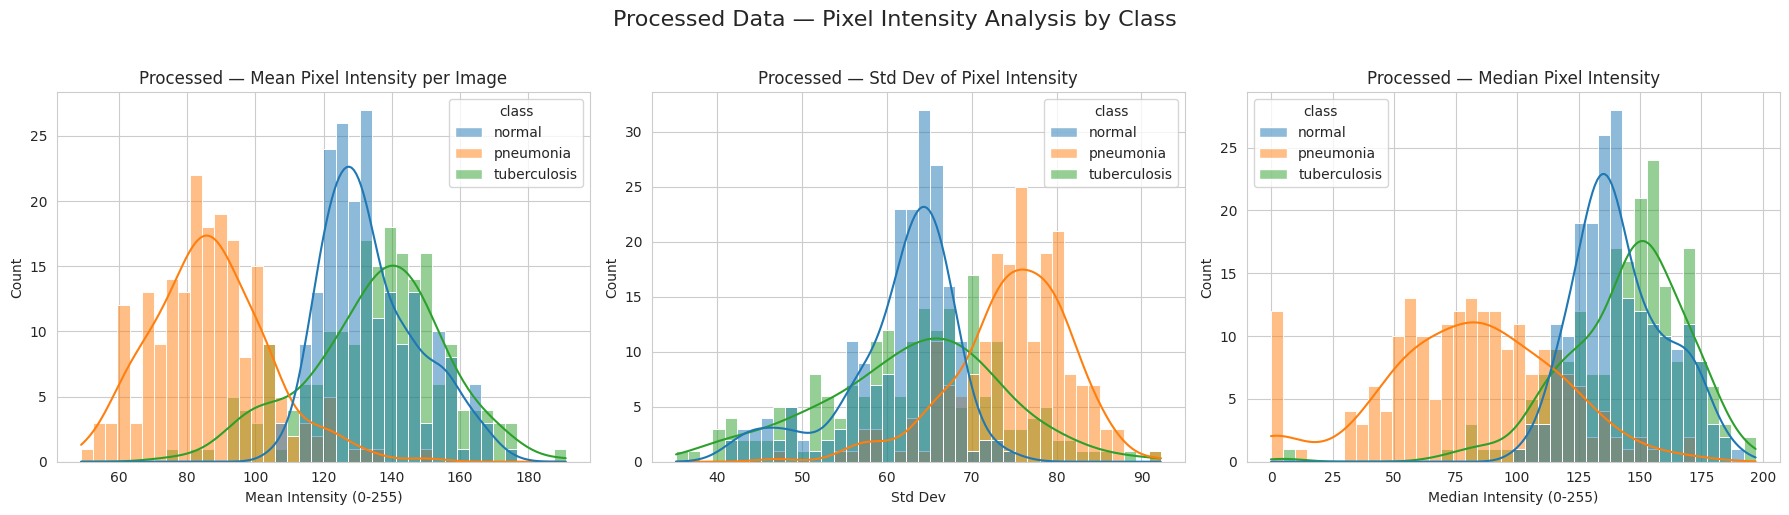


Processed Intensity Statistics by Class:
             mean_intensity            std_intensity      
                       mean        std          mean   std
class                                                     
normal           133.899994  13.800000     61.299999   6.7
pneumonia         86.599998  16.900000     74.599998   6.9
tuberculosis     135.100006  20.200001     62.900002  10.5


In [25]:
if not df_processed.empty:
    proc_intensity = []
    for cls in df_processed["class"].unique():
        class_df = df_processed[df_processed["class"] == cls]
        sample = class_df.sample(n=min(200, len(class_df)), random_state=42)
        for _, row in sample.iterrows():
            try:
                img = Image.open(row["filepath_processed"]).convert("L")
                arr = np.array(img, dtype=np.float32)
                proc_intensity.append({
                    "class": cls,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "median_intensity": np.median(arr),
                })
            except Exception:
                continue

    if proc_intensity:
        proc_intensity_df = pd.DataFrame(proc_intensity)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.histplot(data=proc_intensity_df, x="mean_intensity", hue="class", bins=40, kde=True, ax=axes[0])
        axes[0].set_title("Processed — Mean Pixel Intensity per Image")
        axes[0].set_xlabel("Mean Intensity (0-255)")

        sns.histplot(data=proc_intensity_df, x="std_intensity", hue="class", bins=40, kde=True, ax=axes[1])
        axes[1].set_title("Processed — Std Dev of Pixel Intensity")
        axes[1].set_xlabel("Std Dev")

        sns.histplot(data=proc_intensity_df, x="median_intensity", hue="class", bins=40, kde=True, ax=axes[2])
        axes[2].set_title("Processed — Median Pixel Intensity")
        axes[2].set_xlabel("Median Intensity (0-255)")

        plt.suptitle("Processed Data — Pixel Intensity Analysis by Class", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        print("\nProcessed Intensity Statistics by Class:")
        print(proc_intensity_df.groupby("class")[["mean_intensity", "std_intensity"]].agg(["mean", "std"]).round(1))
    else:
        print("⚠️  Could not read any processed images — check file paths.")
else:
    print("⚠️  No processed data available — skipping.")

## 13. Channel & Color Mode Analysis
Confirm whether all images are grayscale (`L`) or RGB. Mixed modes require normalisation during preprocessing.

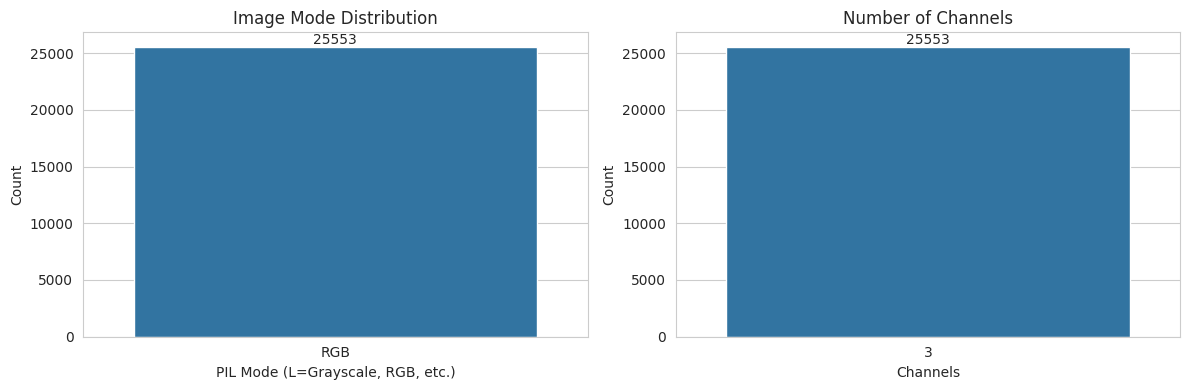


Mode per class:
mode            RGB
class              
normal         9088
pneumonia      5824
tuberculosis  10641

💡 Recommendation: Convert all images to a consistent mode (e.g. RGB or L) during preprocessing.


In [30]:
# Channel / mode breakdown (uses df_stats from section 6)
mode_counts = df_stats["mode"].value_counts()
channel_counts = df_stats["channels"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mode distribution
sns.barplot(x=mode_counts.index.astype(str), y=mode_counts.values, ax=axes[0])
axes[0].set_title("Image Mode Distribution")
axes[0].set_xlabel("PIL Mode (L=Grayscale, RGB, etc.)")
axes[0].set_ylabel("Count")
for i, v in enumerate(mode_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Channel count distribution
sns.barplot(x=channel_counts.index.astype(str), y=channel_counts.values, ax=axes[1])
axes[1].set_title("Number of Channels")
axes[1].set_xlabel("Channels")
axes[1].set_ylabel("Count")
for i, v in enumerate(channel_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Per-class mode breakdown
print("\nMode per class:")
print(df_stats.groupby(["class", "mode"]).size().unstack(fill_value=0))
print("\n💡 Recommendation: Convert all images to a consistent mode (e.g. RGB or L) during preprocessing.")

## 13b. File Format Distribution
Check which image formats are present in the raw dataset.

File Format Distribution:
  .jpg: 25553 (100.0%)

Format per class:
extension      .jpg
class              
normal         9088
pneumonia      5824
tuberculosis  10641


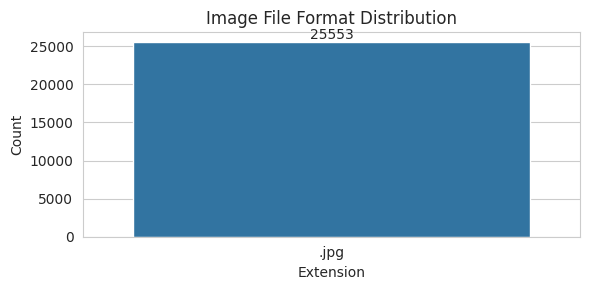


💡 All images are .jpg — use the same format during preprocessing to avoid unnecessary re-encoding.


In [31]:
# File extension distribution
df["extension"] = df["filename"].apply(lambda f: Path(f).suffix.lower())
ext_counts = df["extension"].value_counts()

print("File Format Distribution:")
for ext, count in ext_counts.items():
    pct = count / len(df) * 100
    print(f"  {ext}: {count} ({pct:.1f}%)")

# Per-class breakdown
print("\nFormat per class:")
print(df.groupby(["class", "extension"]).size().unstack(fill_value=0))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=ext_counts.index.astype(str), y=ext_counts.values, ax=ax)
ax.set_title("Image File Format Distribution")
ax.set_xlabel("Extension")
ax.set_ylabel("Count")
for i, v in enumerate(ext_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"\n💡 All images are {ext_counts.index[0]} — use the same format during preprocessing to avoid unnecessary re-encoding.")

## 14. Summary Statistics

In [32]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total raw images:       {len(df)}")
print(f"Number of classes:      {df['class'].nunique() if len(df) > 0 else 0}")
print(f"Classes:                {sorted(df['class'].unique().tolist()) if len(df) > 0 else 'N/A'}")

print("\nRaw class balance:")
if len(df) > 0:
    for cls, count in df["class"].value_counts().items():
        pct = count / len(df) * 100
        print(f"  {cls}: {count} ({pct:.1f}%)")

if "width" in df_stats.columns:
    print(f"\nRaw resolution range:   "
          f"{int(df_stats['width'].min())}x{int(df_stats['height'].min())} -> "
          f"{int(df_stats['width'].max())}x{int(df_stats['height'].max())}")
    print(f"Image modes:            {df_stats['mode'].unique().tolist()}")

print(f"\n--- After Processing Pipeline ---")
if not df_processed.empty:
    print(f"Processed images:       {len(df_processed)}")
else:
    print(f"Processed images:       N/A (run pipeline first)")

try:
    if not df_quarantine.empty:
        n_corrupted = (df_quarantine["category"] == "Corrupted").sum()
        n_flagged = (df_quarantine["category"] == "Flagged").sum()
        print(f"Quarantined (corrupted): {n_corrupted}")
        print(f"Quarantined (flagged):   {n_flagged}")
    else:
        print(f"Quarantined images:     0")
except NameError:
    print(f"Quarantined images:     N/A (run pipeline first)")

print("=" * 60)

DATASET SUMMARY
Total raw images:       25553
Number of classes:      3
Classes:                ['normal', 'pneumonia', 'tuberculosis']

Raw class balance:
  tuberculosis: 10641 (41.6%)
  normal: 9088 (35.6%)
  pneumonia: 5824 (22.8%)

Raw resolution range:   144x124 -> 2916x2863
Image modes:            ['RGB']

--- After Processing Pipeline ---
Processed images:       14354
Quarantined (corrupted): 1
Quarantined (flagged):   19


---
# Part II — NIH ChestX-ray14 EDA

The NIH ChestX-ray14 dataset contains **112,120 frontal-view X-rays** from **30,805 unique patients**, annotated with up to 14 disease labels (multi-label) plus a "No Finding" class.  
This section explores:
1. Raw label distribution across all 14 diseases
2. Multi-label co-occurrence
3. Patient-level statistics (age, gender, images-per-patient)
4. 3-class subset distribution (Cardiomegaly / Pneumonia / No Finding)
5. Official train-val / test split breakdown
6. Sample images from each class


## II-1. Load NIH Metadata

In [3]:
from collections import Counter

NIH_DIR = Path("../NIH_ChestX-ray14")

nih_df = pd.read_csv(NIH_DIR / "Data_Entry_2017.csv")
nih_df.columns = nih_df.columns.str.strip()

# Friendly column aliases
nih_df = nih_df.rename(columns={
    "Image Index":    "image_index",
    "Finding Labels": "finding_labels",
    "Follow-up #":    "followup",
    "Patient ID":     "patient_id",
    "Patient Age":    "age",
    "Patient Gender": "gender",
    "View Position":  "view_position",
})

print(f"Total images     : {len(nih_df):,}")
print(f"Unique patients  : {nih_df['patient_id'].nunique():,}")
print(f"Columns          : {nih_df.columns.tolist()}")
print()
print(nih_df.head(3).to_string(index=False))


Total images     : 112,120
Unique patients  : 30,805
Columns          : ['image_index', 'finding_labels', 'followup', 'patient_id', 'age', 'gender', 'view_position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

     image_index         finding_labels  followup  patient_id  age gender view_position  OriginalImage[Width  Height]  OriginalImagePixelSpacing[x    y]  Unnamed: 11
00000001_000.png           Cardiomegaly         0           1   58      M            PA                 2682     2749                        0.143 0.143          NaN
00000001_001.png Cardiomegaly|Emphysema         1           1   58      M            PA                 2894     2729                        0.143 0.143          NaN
00000001_002.png  Cardiomegaly|Effusion         2           1   58      M            PA                 2500     2048                        0.168 0.168          NaN


## II-2. Full Disease Label Distribution

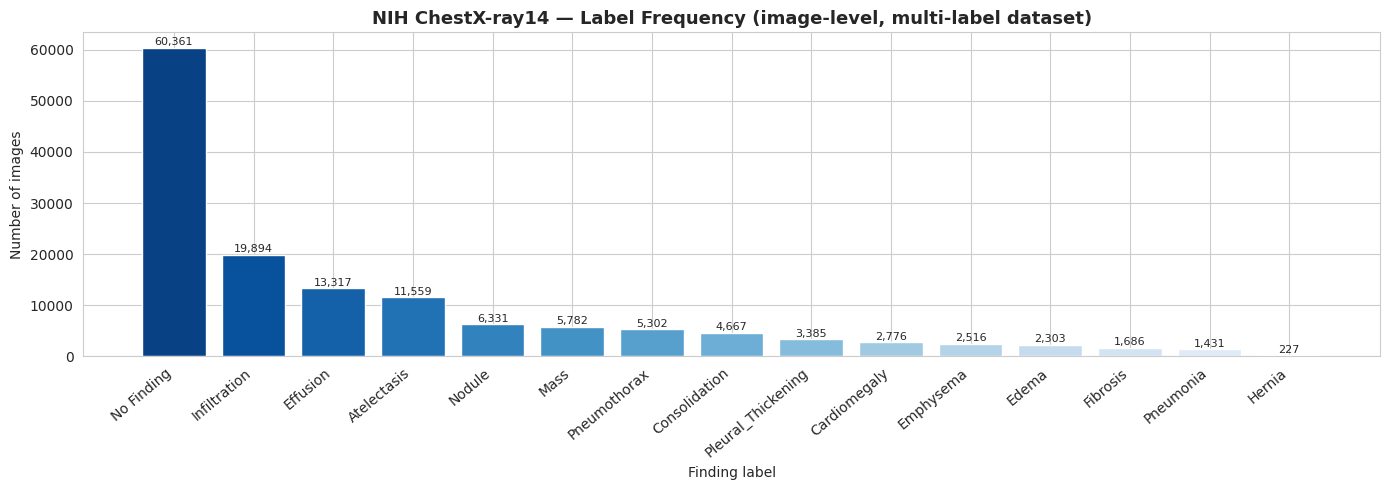


Label counts:
  No Finding                 60,361  (53.8% of images)
  Infiltration               19,894  (17.7% of images)
  Effusion                   13,317  (11.9% of images)
  Atelectasis                11,559  (10.3% of images)
  Nodule                      6,331  (5.6% of images)
  Mass                        5,782  (5.2% of images)
  Pneumothorax                5,302  (4.7% of images)
  Consolidation               4,667  (4.2% of images)
  Pleural_Thickening          3,385  (3.0% of images)
  Cardiomegaly                2,776  (2.5% of images)
  Emphysema                   2,516  (2.2% of images)
  Edema                       2,303  (2.1% of images)
  Fibrosis                    1,686  (1.5% of images)
  Pneumonia                   1,431  (1.3% of images)
  Hernia                        227  (0.2% of images)


In [4]:
# Explode multi-label strings into individual disease counts
all_labels = []
for labels in nih_df["finding_labels"]:
    all_labels.extend(labels.split("|"))

label_counts = pd.Series(Counter(all_labels)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(label_counts.index, label_counts.values,
              color=sns.color_palette("Blues_r", len(label_counts)))
ax.set_title("NIH ChestX-ray14 — Label Frequency (image-level, multi-label dataset)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Number of images")
ax.set_xlabel("Finding label")
plt.xticks(rotation=40, ha="right")
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{val:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print("\nLabel counts:")
for label, cnt in label_counts.items():
    print(f"  {label:<25} {cnt:>7,}  ({cnt/len(nih_df)*100:.1f}% of images)")


## II-3. Multi-Label Co-occurrence Heatmap

Each cell shows how many images share **both** conditions simultaneously.

In [5]:
DISEASES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Effusion", "Emphysema", "Fibrosis", "Hernia",
    "Infiltration", "Mass", "Nodule", "Pleural_Thickening",
    "Pneumonia", "Pneumothorax",
]

# Binary indicator matrix (disease presence per image)
indicator = pd.DataFrame(
    {d: nih_df["finding_labels"].str.contains(d, regex=False).astype(int)
     for d in DISEASES}
)

cooccur = indicator.T.dot(indicator)
np.fill_diagonal(cooccur.values, 0)  # zero diagonal

fig, ax = plt.subplots(figsize=(12, 10))
mask = cooccur == 0
sns.heatmap(
    cooccur, mask=mask, annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.4, ax=ax, cbar_kws={"label": "# co-occurring images"},
    annot_kws={"size": 7},
)
ax.set_title("NIH ChestX-ray14 — Disease Co-occurrence (images sharing both labels)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Images with 0 / 1 / 2+ labels
n_labels = indicator.sum(axis=1)
print("Images by number of disease labels:")
for k, cnt in n_labels.value_counts().sort_index().items():
    tag = "No Finding" if k == 0 else f"{k} disease(s)"
    print(f"  {tag:<20} {cnt:>7,}  ({cnt/len(nih_df)*100:.1f}%)")


ValueError: underlying array is read-only

## II-4. Patient-Level Statistics

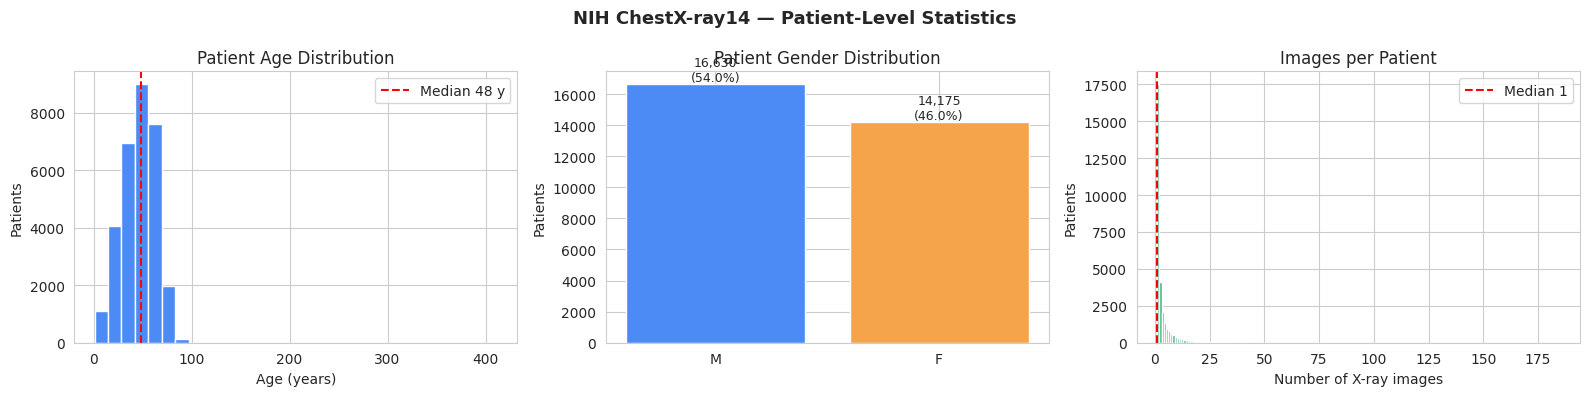

Patients with 1 image:   17,503
Patients with 2+ images: 13,302  (43.2%)
Max images (one patient): 184
Age range: 1 – 412 years  (mean 46.1  median 48)


In [6]:
patient_df = nih_df.drop_duplicates("patient_id").copy()
imgs_per_patient = nih_df.groupby("patient_id").size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Age distribution ---
age_clean = pd.to_numeric(patient_df["age"], errors="coerce").dropna()
axes[0].hist(age_clean, bins=30, color="#4C8BF5", edgecolor="white")
axes[0].set_title("Patient Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patients")
axes[0].axvline(age_clean.median(), color="red", linestyle="--",
                label=f"Median {age_clean.median():.0f} y")
axes[0].legend()

# --- Gender distribution ---
gender_counts = patient_df["gender"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values,
            color=["#4C8BF5", "#F5A44C"], edgecolor="white")
axes[1].set_title("Patient Gender Distribution")
axes[1].set_ylabel("Patients")
for bar, val in zip(axes[1].patches, gender_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val:,}\n({val/len(patient_df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)

# --- Images per patient ---
axes[2].hist(imgs_per_patient.values, bins=range(1, imgs_per_patient.max() + 2),
             color="#45B785", edgecolor="white")
axes[2].set_title("Images per Patient")
axes[2].set_xlabel("Number of X-ray images")
axes[2].set_ylabel("Patients")
axes[2].axvline(imgs_per_patient.median(), color="red", linestyle="--",
                label=f"Median {imgs_per_patient.median():.0f}")
axes[2].legend()

plt.suptitle("NIH ChestX-ray14 — Patient-Level Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Patients with 1 image:   {(imgs_per_patient == 1).sum():,}")
print(f"Patients with 2+ images: {(imgs_per_patient > 1).sum():,}  "
      f"({(imgs_per_patient>1).sum()/len(imgs_per_patient)*100:.1f}%)")
print(f"Max images (one patient): {imgs_per_patient.max()}")
print(f"Age range: {int(age_clean.min())} – {int(age_clean.max())} years  "
      f"(mean {age_clean.mean():.1f}  median {age_clean.median():.0f})")


## II-5. 3-Class Subset: Cardiomegaly / Pneumonia / No Finding

Mirrors the selection logic in `scripts/organize_data.py`:  
- An image is assigned to class `<d>` **only** if it contains that label **and** not the other selected disease.  
- Multi-disease images are excluded (unambiguous single-label classification).

3-class subset (before No-Finding sampling):
--------------------------------------------------
  Cardiomegaly          2,735 images   1,547 patients
  Pneumonia             1,390 images     981 patients
  No Finding           60,361 images   24,907 patients


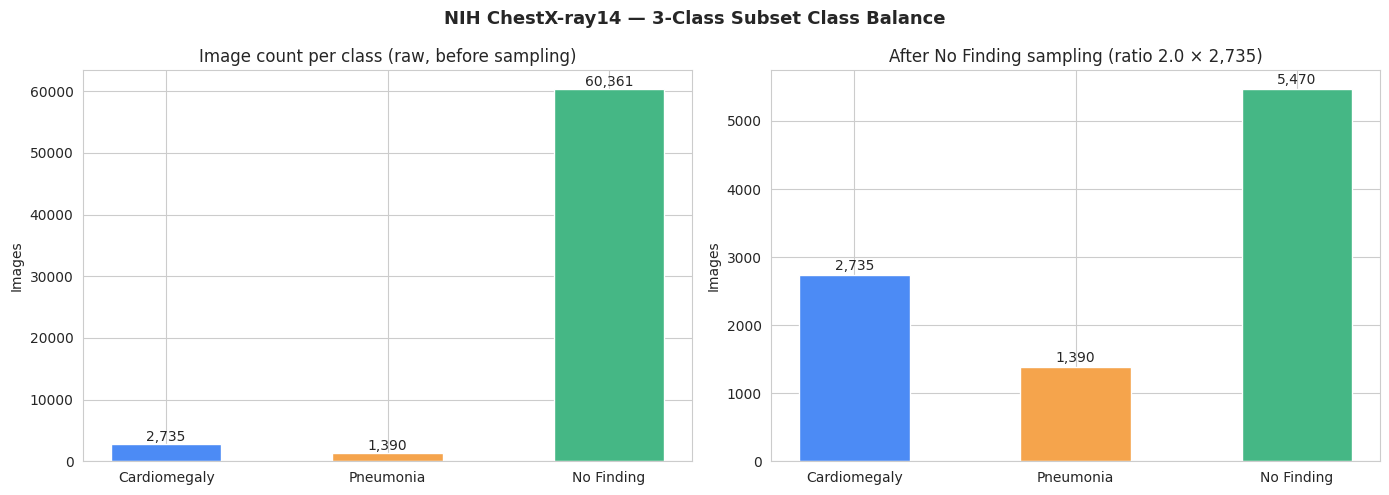


Imbalance ratio (raw):    43.4x
Imbalance ratio (sampled):3.9x


In [7]:
TARGET_DISEASES = ["Cardiomegaly", "Pneumonia"]

def select_subset(df, diseases):
    """Replicate organize_data._select_disease_images logic."""
    class_dfs = {}
    for disease in diseases:
        mask = df["finding_labels"].str.contains(disease, regex=False)
        for other in diseases:
            if other != disease:
                mask = mask & ~df["finding_labels"].str.contains(other, regex=False)
        class_dfs[disease] = df[mask]
    class_dfs["No Finding"] = df[df["finding_labels"] == "No Finding"]
    return class_dfs

subset = select_subset(nih_df, TARGET_DISEASES)

# ---- raw counts ----
print("3-class subset (before No-Finding sampling):")
print("-" * 50)
for cls, sub in subset.items():
    print(f"  {cls:<20} {len(sub):>6,} images   {sub['patient_id'].nunique():>5,} patients")

# ---- bar chart ----
labels  = list(subset.keys())
counts  = [len(v) for v in subset.values()]
palette = ["#4C8BF5", "#F5A44C", "#45B785"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, counts, color=palette, edgecolor="white", width=0.5)
axes[0].set_title("Image count per class (raw, before sampling)")
axes[0].set_ylabel("Images")
for bar, val in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom")

# After sampling No Finding at 2x max-disease
max_disease = max(len(subset[d]) for d in TARGET_DISEASES)
sampled_nf  = int(round(2.0 * max_disease))
sampled_nf  = min(sampled_nf, len(subset["No Finding"]))
sampled_counts = [len(subset[d]) for d in TARGET_DISEASES] + [sampled_nf]
axes[1].bar(labels, sampled_counts, color=palette, edgecolor="white", width=0.5)
axes[1].set_title(f"After No Finding sampling (ratio 2.0 × {max_disease:,})")
axes[1].set_ylabel("Images")
for bar, val in zip(axes[1].patches, sampled_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom")

plt.suptitle("NIH ChestX-ray14 — 3-Class Subset Class Balance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (raw):    {max(counts) / min(counts):.1f}x")
print(f"Imbalance ratio (sampled):{max(sampled_counts) / min(sampled_counts):.1f}x")


## II-6. Train / Val / Test Split Distribution

Loads `data/NIH-ChestX-ray3/manifest.csv` produced by `organize_data.py`.  
Run `python scripts/organize_data.py` first if the manifest does not yet exist.

Manifest loaded: 9,595 records

 split         train  val  test  total
class                                
cardiomegaly   1336  353  1046   2735
no_finding     3695  881   894   5470
pneumonia       703  155   532   1390


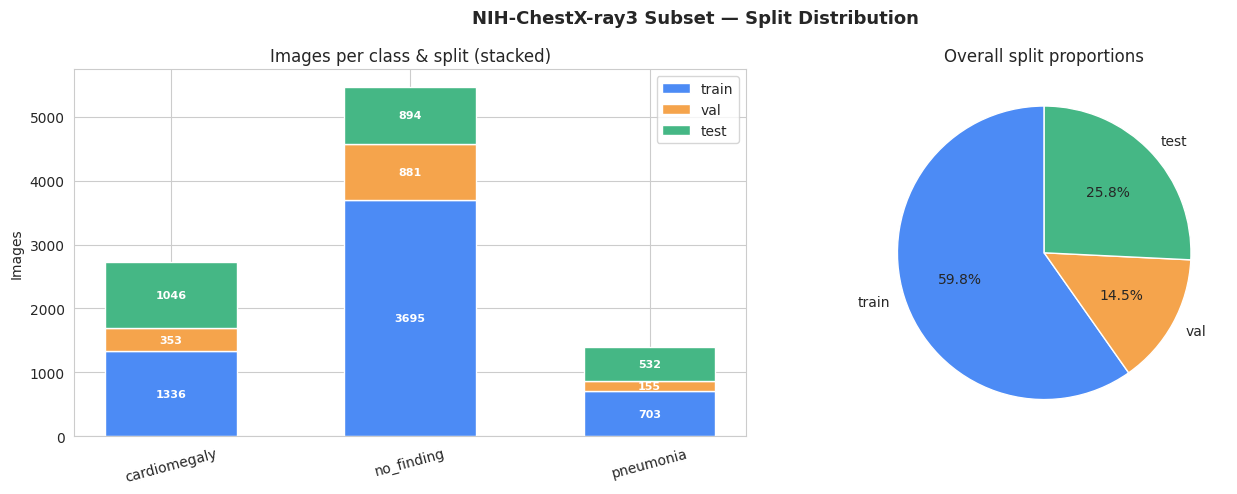


Patient leakage check: 0 patients appear in >1 split (PASS ✓)


In [8]:
MANIFEST_PATH = Path("../data/NIH-ChestX-ray3/manifest.csv")

if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    print(f"Manifest loaded: {len(manifest):,} records")

    pivot = manifest.groupby(["class", "split"]).size().unstack(fill_value=0)
    pivot = pivot[["train", "val", "test"]]          # enforce column order
    pivot["total"] = pivot.sum(axis=1)
    print("\n", pivot.to_string())

    # Stacked bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    classes = pivot.index.tolist()
    x = np.arange(len(classes))
    w = 0.55
    split_colors = {"train": "#4C8BF5", "val": "#F5A44C", "test": "#45B785"}

    bottom = np.zeros(len(classes))
    for split in ["train", "val", "test"]:
        vals = pivot[split].values
        bars = axes[0].bar(x, vals, w, bottom=bottom,
                           label=split, color=split_colors[split])
        # Label inside bar if big enough
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 50:
                axes[0].text(bar.get_x() + w / 2, bot + val / 2,
                             str(val), ha="center", va="center",
                             fontsize=8, color="white", fontweight="bold")
        bottom += vals
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(classes, rotation=15)
    axes[0].set_title("Images per class & split (stacked)")
    axes[0].set_ylabel("Images")
    axes[0].legend()

    # Overall split percentages
    split_totals = manifest["split"].value_counts()[["train", "val", "test"]]
    axes[1].pie(split_totals, labels=split_totals.index,
                autopct="%1.1f%%", startangle=90,
                colors=[split_colors[s] for s in split_totals.index])
    axes[1].set_title("Overall split proportions")

    plt.suptitle("NIH-ChestX-ray3 Subset — Split Distribution", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Patient-leakage sanity check
    patient_splits = manifest.groupby("patient_id")["split"].nunique()
    leakers = (patient_splits > 1).sum()
    print(f"\nPatient leakage check: {leakers} patients appear in >1 split "
          f"({'FAIL ✗' if leakers else 'PASS ✓'})")
else:
    print(f"Manifest not found at {MANIFEST_PATH}.")
    print("Run:  python scripts/organize_data.py")


## II-7. Sample Images per Class

Image index built: 112,120 files


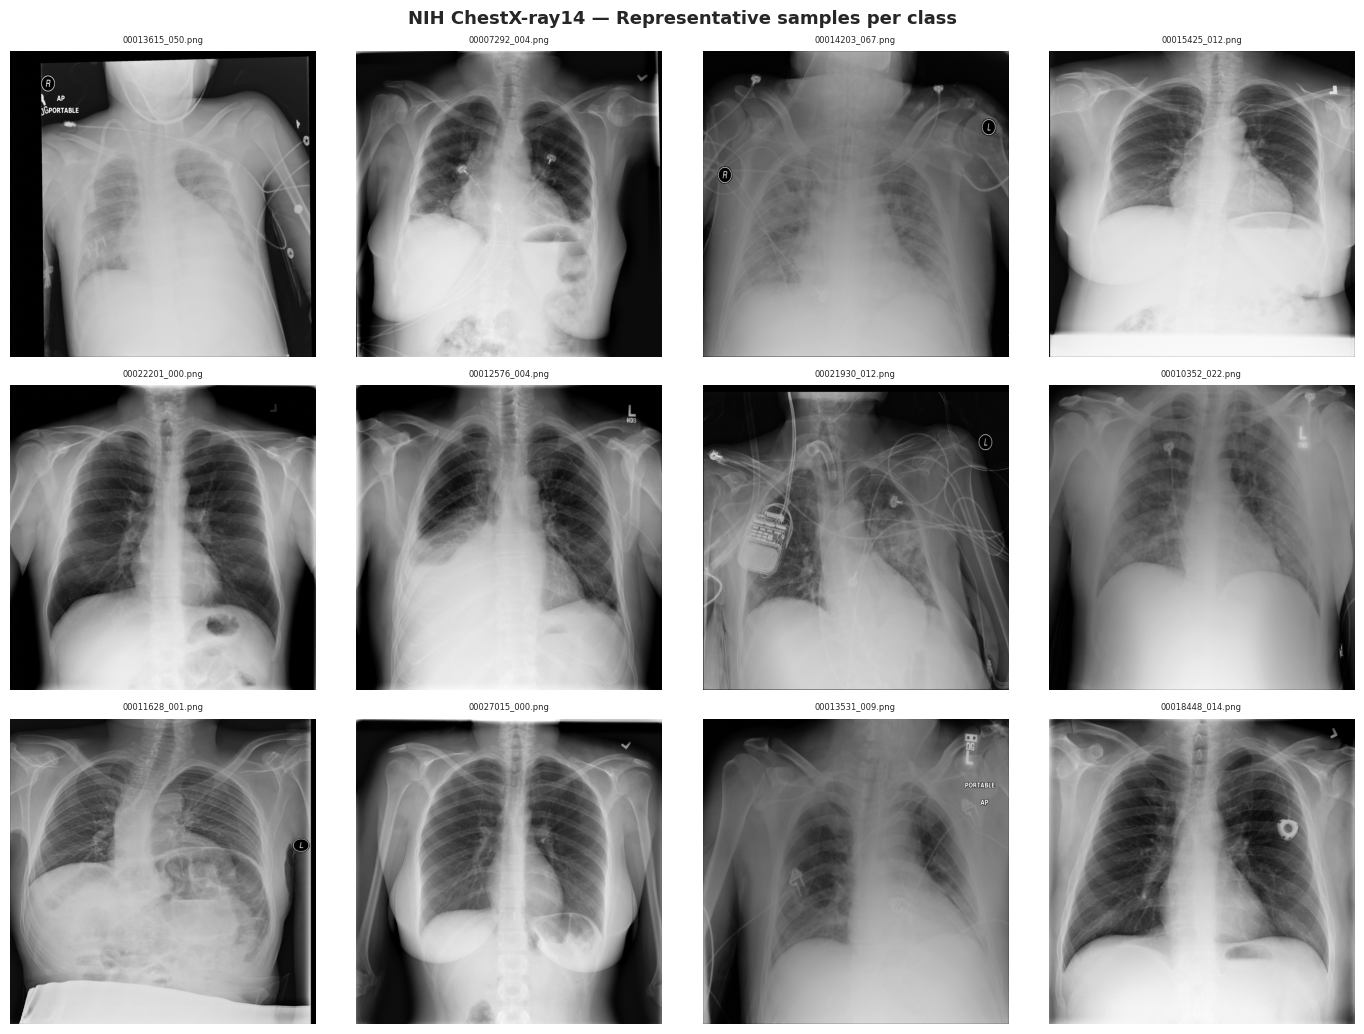

In [9]:
import random
import functools

# Build filename -> path index (cached so we only scan once)
@functools.lru_cache(maxsize=1)
def _nih_index():
    idx = {}
    for img_dir in sorted(NIH_DIR.glob("images_*/images")):
        for p in img_dir.iterdir():
            idx[p.name] = p
    return idx

nih_index = _nih_index()
print(f"Image index built: {len(nih_index):,} files")

def get_class_samples(class_name, n=4, seed=42):
    """Pick n existing image paths for a given class from the NIH dataframe."""
    rng = random.Random(seed)
    if class_name == "No Finding":
        candidates = nih_df.loc[nih_df["finding_labels"] == "No Finding", "image_index"].tolist()
    else:
        candidates = nih_df.loc[
            nih_df["finding_labels"].str.contains(class_name, regex=False),
            "image_index"
        ].tolist()
    rng.shuffle(candidates)
    found = []
    for fname in candidates:
        p = nih_index.get(fname)
        if p and p.exists():
            found.append(p)
        if len(found) == n:
            break
    return found

CLASSES = ["Cardiomegaly", "Pneumonia", "No Finding"]
N_SAMPLES = 4

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES, figsize=(14, 3.5 * len(CLASSES)))

for r, cls in enumerate(CLASSES):
    samples = get_class_samples(cls, n=N_SAMPLES, seed=0)
    for c in range(N_SAMPLES):
        ax = axes[r][c]
        if c < len(samples):
            try:
                img = Image.open(samples[c]).convert("L")
                ax.imshow(img, cmap="gray")
                ax.set_title(samples[c].name, fontsize=6)
            except Exception as err:
                ax.text(0.5, 0.5, f"Load error\n{err}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=7)
        else:
            ax.text(0.5, 0.5, "No image found", ha="center", va="center",
                    transform=ax.transAxes)
        ax.axis("off")
        if c == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold",
                          rotation=0, labelpad=80, va="center")

plt.suptitle("NIH ChestX-ray14 — Representative samples per class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## II-8. NIH Subset Summary

In [10]:
print("=" * 60)
print("NIH CHESTX-RAY14 DATASET SUMMARY")
print("=" * 60)
print(f"Total images         : {len(nih_df):,}")
print(f"Unique patients      : {nih_df['patient_id'].nunique():,}")
print(f"Disease labels       : {len(DISEASES)}")
print(f"Multi-label images   : {(indicator.sum(axis=1) > 1).sum():,}  "
      f"({(indicator.sum(axis=1) > 1).sum()/len(nih_df)*100:.1f}%)")
print(f"No Finding images    : {(nih_df['finding_labels']=='No Finding').sum():,}")

print()
print("3-CLASS SUBSET (Cardiomegaly / Pneumonia / No Finding)")
print("-" * 60)
for cls, sub in subset.items():
    print(f"  {cls:<20} {len(sub):>6,} images   "
          f"{sub['patient_id'].nunique():>5,} patients")

if MANIFEST_PATH.exists():
    print()
    print("FINAL SPLIT (after organize_data.py)")
    print("-" * 60)
    for sp in ["train", "val", "test"]:
        n = (manifest["split"] == sp).sum()
        print(f"  {sp:<8} {n:>6,}  ({n/len(manifest)*100:.1f}%)")
    print(f"  {'TOTAL':<8} {len(manifest):>6,}")
print("=" * 60)


NIH CHESTX-RAY14 DATASET SUMMARY
Total images         : 112,120
Unique patients      : 30,805
Disease labels       : 14
Multi-label images   : 20,796  (18.5%)
No Finding images    : 60,361

3-CLASS SUBSET (Cardiomegaly / Pneumonia / No Finding)
------------------------------------------------------------
  Cardiomegaly          2,735 images   1,547 patients
  Pneumonia             1,390 images     981 patients
  No Finding           60,361 images   24,907 patients

FINAL SPLIT (after organize_data.py)
------------------------------------------------------------
  train     5,734  (59.8%)
  val       1,389  (14.5%)
  test      2,472  (25.8%)
  TOTAL     9,595


In [ ]:
import pytorch_lightning as pl
